In [1]:
!pip install pandas numpy scikit-learn nltk spacy matplotlib seaborn

   ---------------------------------------- 0.0/14.4 MB ? eta -:--:--
    --------------------------------------- 0.3/14.4 MB ? eta -:--:--
   - -------------------------------------- 0.5/14.4 MB 2.0 MB/s eta 0:00:07
   -- ------------------------------------- 1.0/14.4 MB 2.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.8/14.4 MB 2.5 MB/s eta 0:00:06
   ------- -------------------------------- 2.6/14.4 MB 2.8 MB/s eta 0:00:05
   --------- ------------------------------ 3.4/14.4 MB 3.0 MB/s eta 0:00:04
   ------------ --------------------------- 4.5/14.4 MB 3.3 MB/s eta 0:00:03
   --------------- ------------------------ 5.5/14.4 MB 3.6 MB/s eta 0:00:03
   ------------------ --------------------- 6.8/14.4 MB 3.9 MB/s eta 0:00:02
   --------------------- ------------------ 7.9/14.4 MB 4.1 MB/s eta 0:00:02
   ------------------------- -------------- 9.2/14.4 MB 4.3 MB/s eta 0:00:02
   ---------------------------- ----------- 10.2/14.4 MB 4.4 MB/s eta 0:00:01
   ---------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Aishwarya S\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import nltk
import spacy

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

import re

C:\Users\Aishwarya S\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\confection\__init__.py:38: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel, Extra, ValidationError, create_model


ConfigError: unable to infer type for attribute "REGEX"

In [3]:
!python -m spacy download en_core_web_sm

C:\Users\Aishwarya S\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\confection\__init__.py:38: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel, Extra, ValidationError, create_model
Traceback (most recent call last):
  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 148, in _get_module_details
  File "<frozen runpy>", line 112, in _get_module_details
  File "C:\Users\Aishwarya S\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\spacy\__init__.py", line 13, in <module>
    from . import pipeline  # noqa: F401
    ^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Aishwarya S\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\spacy\pipeline\__init__.py", line 1, in <module>
    from .attributeruler import AttributeRuler
  File "C:\Users\Aishwarya S\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\spacy\pipeline\attributeruler.py", line 10, in <module>

In [1]:
import spacy
print("spaCy working!")

spaCy working!


In [3]:
!python -m spacy download en_core_web_sm

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import spacy

nlp = spacy.load("en_core_web_sm")

print("spaCy model loaded successfully")

spaCy model loaded successfully


In [5]:
import pandas as pd

df = pd.read_csv("Resume.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Resume.csv'

In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Aishwarya S\Downloads\archive (1)\Resume\Resume.csv")

df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [5]:
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to C:\Users\Aishwarya
[nltk_data]     S\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

print(list(stop_words)[:20])

['nor', 'aren', 'against', 'needn', 'as', 'why', 'are', "that'll", 'didn', 'most', 'itself', 'me', 'o', 'off', 'there', 'own', 'do', "you're", 'yourself', 'being']


In [7]:
import re

def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    
    words = text.split()
    
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

In [8]:
df["cleaned_resume"] = df["Resume"].apply(clean_text)

df.head()

KeyError: 'Resume'

In [9]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='str')

In [10]:
df["cleaned_resume"] = df["Resume_str"].apply(clean_text)

df.head()

,ID,Resume_str,Resume_html,Category,cleaned_resume
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr administrator marketing associate hr admini...
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist us hr operations summary versati...
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr director summary years experience recruitin...
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist summary dedicated driven dynamic...
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr manager skill highlights hr skills hr depar...


In [11]:
print(df["cleaned_resume"][0])

hr administrator marketing associate hr administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customer focused teams strives instill shared enthusiastic commitment customer service highlights focused customer satisfaction team management marketing savvy conflict resolution techniques training development skilled multi tasker client relations specialist accomplishments missouri dot supervisor training certification certified ihg customer loyalty marketing segment hilton worldwide general manager training certification accomplished trainer cross server hospitality systems hilton onq micros opera pms fidelio opera reservation system ors holidex completed courses seminars customer service sales strategies inventory control loss prevention safety time management leadership performance assessment experience hr administrator marketing associate hr administrator dec current company name city state helps develo

In [12]:
job_description = """
Looking for a Data Scientist with skills in Python, Machine Learning,
Data Analysis, SQL, Statistics, Deep Learning, NLP, and Data Visualization.
Experience with Pandas, NumPy, Scikit-learn and TensorFlow preferred.
"""

In [13]:
clean_job = clean_text(job_description)

clean_job


'looking data scientist skills python machine learning data analysis sql statistics deep learning nlp data visualization experience pandas numpy scikit learn tensorflow preferred'

In [15]:
documents = df["cleaned_resume"].tolist()


documents.append(clean_job)

KeyError: 'cleaned_resume'

In [16]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='str')

In [18]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

In [19]:
df["cleaned_resume"] = df["Resume_str"].apply(clean_text)

df.head()

,ID,Resume_str,Resume_html,Category,cleaned_resume
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr administrator marketing associate hr admini...
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist us hr operations summary versati...
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr director summary years experience recruitin...
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist summary dedicated driven dynamic...
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr manager skill highlights hr skills hr depar...


In [20]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category', 'cleaned_resume'], dtype='str')

In [21]:
documents = df["cleaned_resume"].tolist()

documents.append(clean_job)

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(documents)

In [23]:
resume_vectors = tfidf_matrix[:-1]

job_vector = tfidf_matrix[-1]

In [24]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_scores = cosine_similarity(resume_vectors, job_vector)

In [25]:
df["similarity_score"] = similarity_scores

In [26]:
ranked_candidates = df.sort_values(by="similarity_score", ascending=False)

ranked_candidates[["Category","similarity_score"]].head(10)

,Category,similarity_score
926,AGRICULTURE,0.233853
1339,AUTOMOBILE,0.215995
1218,CONSULTANT,0.212440
1762,ENGINEERING,0.196261
1040,SALES,0.117334
2153,BANKING,0.117221
1303,DIGITAL-MEDIA,0.116347
331,INFORMATION-TECHNOLOGY,0.110721
1142,CONSULTANT,0.109085
1091,SALES,0.108333


In [27]:
skills = [
    "python","machine learning","sql","nlp","deep learning",
    "data analysis","pandas","numpy","tensorflow","statistics",
    "tableau","power bi","excel","data visualization"
]

In [28]:
def extract_skills(text):
    
    found_skills = []
    
    for skill in skills:
        if skill in text:
            found_skills.append(skill)
            
    return found_skills

In [29]:
df["skills_found"] = df["cleaned_resume"].apply(extract_skills)

df.head()

,ID,Resume_str,Resume_html,Category,cleaned_resume,similarity_score,skills_found
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr administrator marketing associate hr admini...,0.032294,"[data analysis, statistics]"
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist us hr operations summary versati...,0.000884,[]
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr director summary years experience recruitin...,0.001341,[excel]
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist summary dedicated driven dynamic...,0.003522,[excel]
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr manager skill highlights hr skills hr depar...,0.004037,[excel]


In [30]:
job_skills = extract_skills(clean_job)

job_skills

['python',
 'machine learning',
 'sql',
 'nlp',
 'deep learning',
 'data analysis',
 'pandas',
 'numpy',
 'tensorflow',
 'statistics',
 'data visualization']

In [31]:
def missing_skills(resume_skills):
    
    missing = []
    
    for skill in job_skills:
        if skill not in resume_skills:
            missing.append(skill)
            
    return missing

In [32]:
df["missing_skills"] = df["skills_found"].apply(missing_skills)

df.head()

,ID,Resume_str,Resume_html,Category,cleaned_resume,similarity_score,skills_found,missing_skills
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr administrator marketing associate hr admini...,0.032294,"[data analysis, statistics]","[python, machine learning, sql, nlp, deep lear..."
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist us hr operations summary versati...,0.000884,[],"[python, machine learning, sql, nlp, deep lear..."
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr director summary years experience recruitin...,0.001341,[excel],"[python, machine learning, sql, nlp, deep lear..."
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist summary dedicated driven dynamic...,0.003522,[excel],"[python, machine learning, sql, nlp, deep lear..."
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr manager skill highlights hr skills hr depar...,0.004037,[excel],"[python, machine learning, sql, nlp, deep lear..."


In [33]:
ranked_candidates = df.sort_values(by="similarity_score", ascending=False)

ranked_candidates[["Category","similarity_score","skills_found","missing_skills"]].head(10)

,Category,similarity_score,skills_found,missing_skills
926,AGRICULTURE,0.233853,"[python, sql, pandas, tensorflow, tableau, exc...","[machine learning, nlp, deep learning, data an..."
1339,AUTOMOBILE,0.215995,"[python, sql, data analysis, pandas, numpy, st...","[machine learning, nlp, deep learning, tensorf..."
1218,CONSULTANT,0.212440,"[python, machine learning, sql, data analysis,...","[nlp, deep learning, pandas, numpy, tensorflow..."
1762,ENGINEERING,0.196261,"[python, machine learning, sql, data analysis,...","[nlp, deep learning, numpy, tensorflow]"
1040,SALES,0.117334,"[machine learning, data analysis, statistics, ...","[python, sql, nlp, deep learning, pandas, nump..."
2153,BANKING,0.117221,"[python, machine learning, sql]","[nlp, deep learning, data analysis, pandas, nu..."
1303,DIGITAL-MEDIA,0.116347,"[python, sql, tableau, power bi, excel]","[machine learning, nlp, deep learning, data an..."
331,INFORMATION-TECHNOLOGY,0.110721,"[python, sql, data analysis, tableau, excel]","[machine learning, nlp, deep learning, pandas,..."
1142,CONSULTANT,0.109085,"[sql, tableau, excel]","[python, machine learning, nlp, deep learning,..."
1091,SALES,0.108333,"[sql, tableau, excel]","[python, machine learning, nlp, deep learning,..."


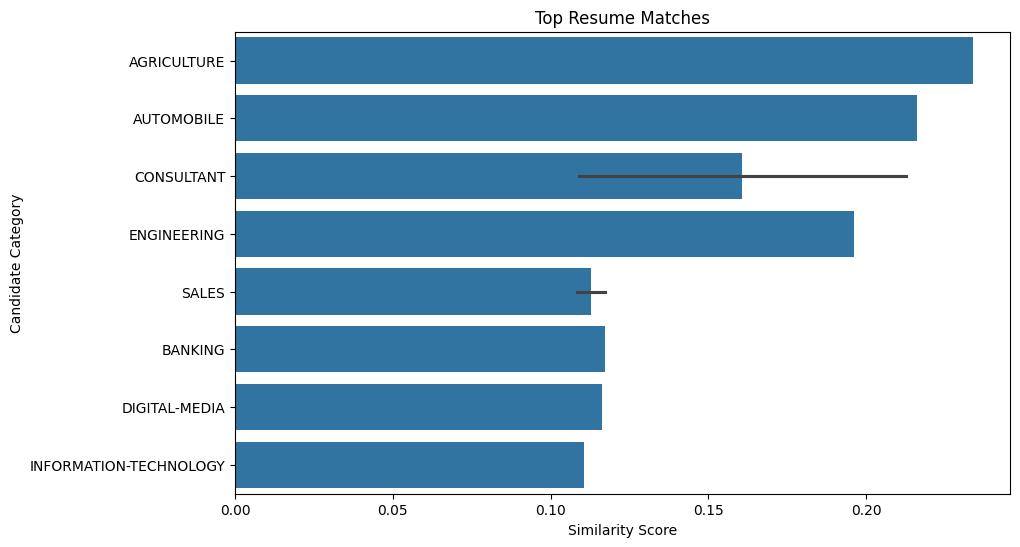

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

top10 = ranked_candidates.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top10["similarity_score"],
    y=top10["Category"]
)

plt.title("Top Resume Matches")
plt.xlabel("Similarity Score")
plt.ylabel("Candidate Category")

plt.show()